# Język Python w Analizie Danych
# Lab08 - Mistrzostw Świata - Sprawozdanie

Autor: Piotr Przymus 127902

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### Krok 1 - Wczytanie danych
Wczytałem oba pliki CSV do obiektów `pandas.DataFrame` i sprawdziłem ich rozmiar oraz podstawową strukturę.

In [3]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print("Zbiór treningowy:", train.shape)
print("Zbiór testowy (2026):", test.shape)
print("\nEdycje w danych treningowych:", sorted(train["version"].unique()))
print("Edycja w danych testowych:", sorted(test["version"].unique()))

train.head()

Zbiór treningowy: (192, 24)
Zbiór testowy (2026): (48, 24)

Edycje w danych treningowych: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
Edycja w danych testowych: [np.int64(2026)]


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,squad_total_market_value_eur,fifa_rank_pre_tournament,fifa_points_pre_tournament,squad_avg_age,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,52700000.0,57,581.0,29.2,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,777200000.0,9,746.0,27.8,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,48030000.0,42,612.0,27.1,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,858500000.0,1,827.0,27.1,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,18400000.0,26,683.0,24.7,2,1,1,0,0,0,0,0,0,0


Zbiór treningowy zawiera 192 obserwacje (32 drużyny × 6 turniejów), a testowy 48 drużyn biorących udział w MŚ 2026. Każdy wiersz opisuje jedną reprezentację przed rozpoczęciem turnieju.

### Krok 2 – EDA: typy danych i braki
Sprawdziłem typy kolumn, liczbę brakujących wartości oraz rozkład zmiennych docelowych w zbiorze treningowym.

In [7]:
print(train.info())
print("\nBraki w train:")
print(train.isnull().sum())
print("\nBraki w test (oczekiwane - brak etykiet):")
print(test.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          192 non-null    int64  
 1   team                             192 non-null    str    
 2   continent                        192 non-null    str    
 3   is_host                          192 non-null    int64  
 4   goals_scored_last_4y             192 non-null    int64  
 5   goals_received_last_4y           192 non-null    int64  
 6   wins_last_4y                     192 non-null    int64  
 7   losses_last_4y                   192 non-null    int64  
 8   draws_last_4y                    192 non-null    int64  
 9   world_cup_titles_before          192 non-null    int64  
 10  squad_total_market_value_eur     160 non-null    float64
 11  fifa_rank_pre_tournament         192 non-null    int64  
 12  fifa_points_pre_tournament       

W `train` braki występują tylko w kolumnie `squad_total_market_value`. W `test` jedyne "braki" danych występują w kolumnach `winner`, `finalist`, `semi_finalist` oraz `quarter_finalist` - są one zmiennymi docelowymi.

  quarter_finalist: 48 (25.0%)
  semi_finalist: 24 (12.5%)
  finalist: 12 (6.2%)
  winner: 6 (3.1%)


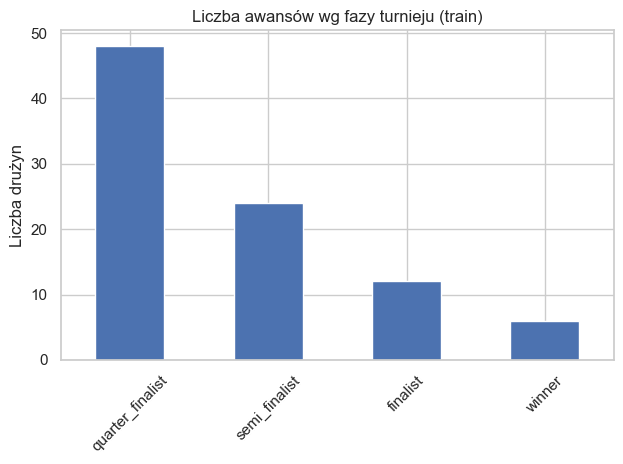

In [10]:
target_cols = ["quarter_finalist", "semi_finalist", "finalist", "winner"]

for col in target_cols:
    print(f"  {col}: {train[col].sum()} ({train[col].mean()*100:.1f}%)")

train[target_cols].sum().plot(kind="bar", title="Liczba awansów wg fazy turnieju (train)")
plt.ylabel("Liczba drużyn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Zmienne docelowe są binarne (0/1). W każdej edycji MŚ awansuje dokładnie 8 drużyn do ćwierćfinałów, 4 do półfinałów, 2 do finału i 1 wygrywa turniej - stąd silna nierównowaga klas (tylko 6 zwycięzców na 192 obserwacje itp.).

### Krok 3 - EDA: historia turniejów
Przeanalizowałem, które reprezentacje osiągały najlepsze wyniki w danych historycznych oraz rozkład drużyn według kontynentów.

Mistrzowie świata w danych treningowych:
 version      team
    2006     Italy
    2018    France
    2022 Argentina
    2010     Spain
    2014   Germany
    2002    Brazil


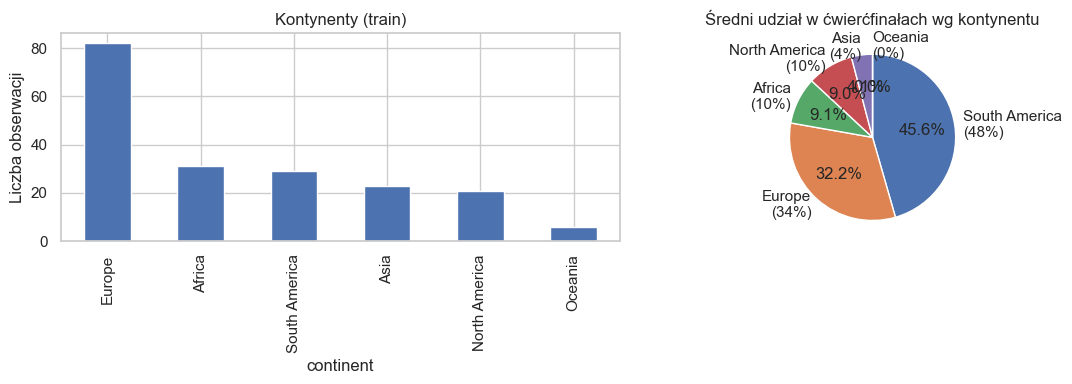

In [16]:
winners = train[train["winner"] == 1][["version", "team"]]
print("Mistrzowie świata w danych treningowych:")
print(winners.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train["continent"].value_counts().plot(kind="bar", ax=axes[0], title="Kontynenty (train)")
axes[0].set_ylabel("Liczba obserwacji")

quarter_by_continent = train.groupby("continent")["quarter_finalist"].mean().sort_values(ascending=False)
pie_labels = [f"{name}\n({rate:.0%})" for name, rate in quarter_by_continent.items()]
axes[1].pie(
    quarter_by_continent,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
axes[1].set_title("Średni udział w ćwierćfinałach wg kontynentu")

plt.tight_layout()
plt.show()

### Krok 4 - EDA: cechy numeryczne
Zbadałem rozkład wybranych cech numerycznych oraz korelację z awansem do ćwierćfinałów.

In [12]:
numeric_cols = [
    "fifa_rank_pre_tournament",
    "fifa_points_pre_tournament",
    "squad_total_market_value_eur",
    "squad_avg_age",
    "goals_scored_last_4y",
    "wins_last_4y",
]

train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fifa_rank_pre_tournament,192.0,2.354167e+01,1.821450e+01,1.00,9.00,2.000000e+01,34.0,1.050000e+02
fifa_points_pre_tournament,192.0,9.541655e+02,3.675446e+02,285.00,670.50,8.240000e+02,1182.5,1.841300e+03
squad_total_market_value_eur,160.0,3.433053e+08,3.489032e+08,6270000.00,93857500.00,2.179400e+08,412975000.0,1.620000e+09
squad_avg_age,192.0,2.724964e+01,1.092351e+00,23.92,26.56,2.722500e+01,28.0,2.978000e+01
goals_scored_last_4y,192.0,8.458333e+01,2.373178e+01,28.00,66.00,8.350000e+01,102.0,1.560000e+02
wins_last_4y,192.0,2.604688e+01,6.912534e+00,8.00,21.00,2.500000e+01,31.0,4.800000e+01


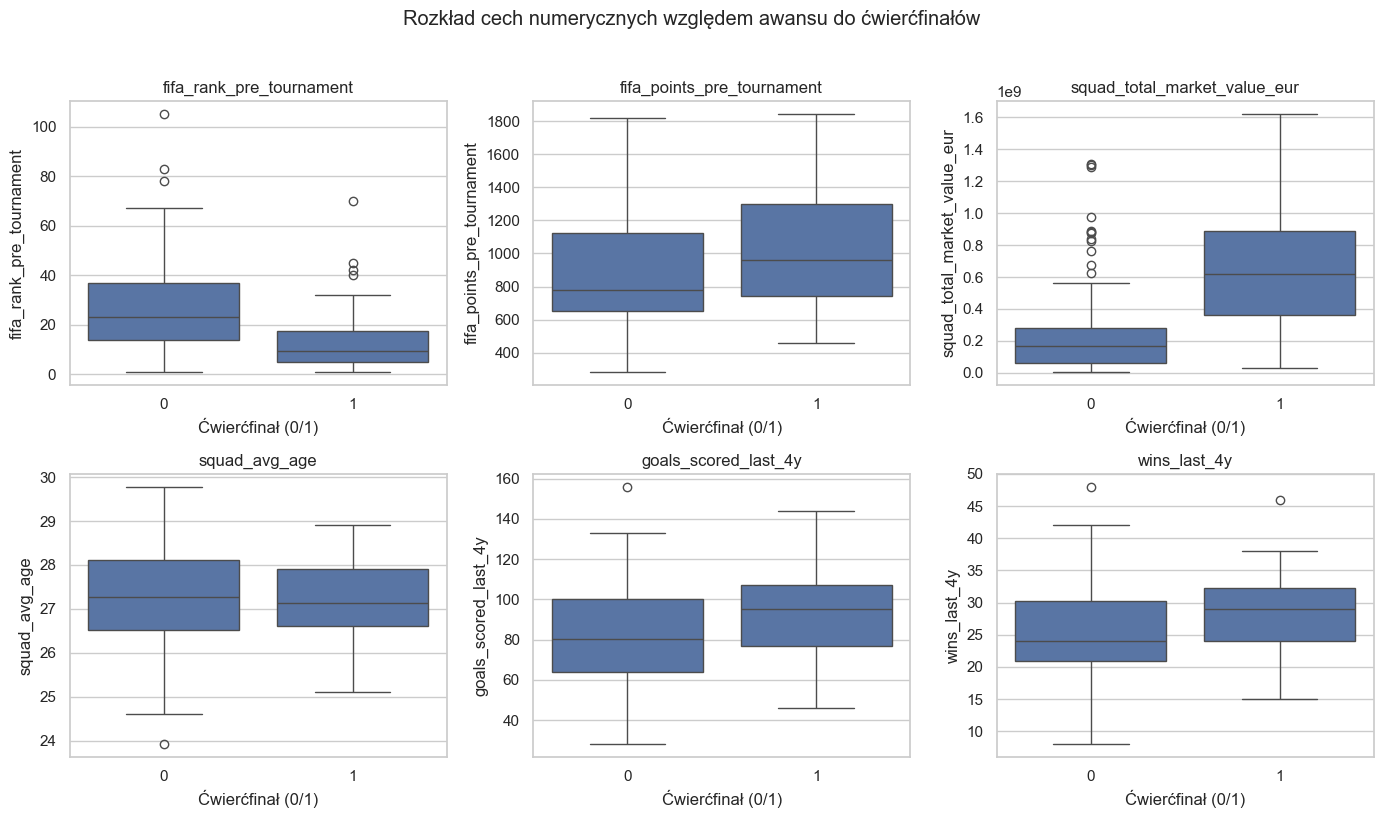

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=train, x="quarter_finalist", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Ćwierćfinał (0/1)")

plt.suptitle("Rozkład cech numerycznych względem awansu do ćwierćfinałów", y=1.02)
plt.tight_layout()
plt.show()

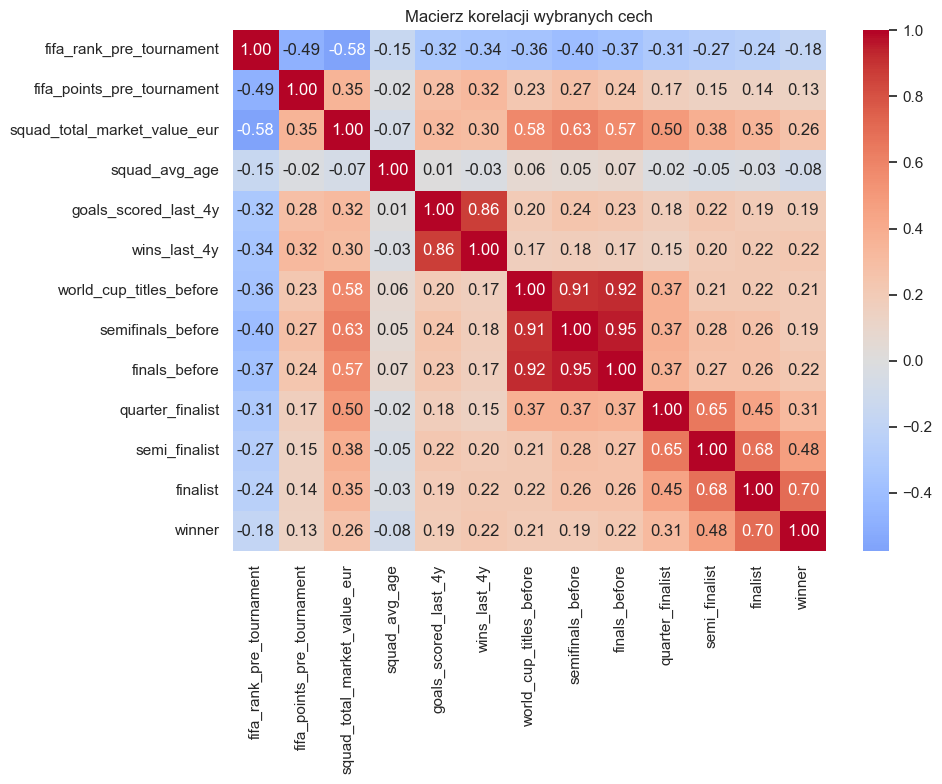

In [8]:
corr_cols = numeric_cols + ["world_cup_titles_before", "semifinals_before", "finals_before"] + target_cols
corr = train[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Macierz korelacji wybranych cech")
plt.tight_layout()
plt.show()

Między dawniejszą wygraną turnieju, udziałem w finale i udziałem w półfinale występuje bardzo silna korelacja (0.90+). Te zmienne mają również umiarkowaną korelację ze zmienną dotyczącą rynkowej wartości składu. Naturalnie między udziałem w finale danego turnieju i zwycięstwem w nim również jest silna korelacja.Umiarkowana korelacja występuje również m.in. między `fifa_rank_pre_tournament` a `fifa_points_pre_tournament`.

### Krok 5 - Przygotowanie danych do modelu

Braki w kolumnie z wartością rynkową składu uzupełnię medianą.

In [15]:
median_market_value = train["squad_total_market_value_eur"].median()

train["squad_total_market_value_eur"] = train["squad_total_market_value_eur"].fillna(median_market_value)

print(f"Uzupełniono braki w wartości składu medianą: {median_market_value:,.0f} EUR")
print("Braki po uzupełnieniu (train):", train["squad_total_market_value_eur"].isnull().sum())
print("Braki po uzupełnieniu (test):", test["squad_total_market_value_eur"].isnull().sum())

Uzupełniono braki w wartości składu medianą: 217,940,000 EUR
Braki po uzupełnieniu (train): 0
Braki po uzupełnieniu (test): 0


Zdefiniowałem cechy wejściowe (X) oraz cztery zmienne docelowe (y). Zmienną kategoryczną `continent` zakodowałem liczbowo za pomocą `LabelEncoder`. Kolumny identyfikujące (`team`) oraz etykiety nie trafiają do modelu.

In [10]:
feature_cols = [
    c
    for c in train.columns
    if c not in ["team", "winner", "finalist", "semi_finalist", "quarter_finalist"]
]

le_continent = LabelEncoder()


def prepare_features(df):
    X = df[feature_cols].copy()
    X["continent"] = le_continent.transform(X["continent"].astype(str))
    return X


le_continent.fit(pd.concat([train["continent"], test["continent"]]).astype(str))

X_train = prepare_features(train)
X_test = prepare_features(test)

print("Liczba cech:", X_train.shape[1])
print("Cechy:", list(X_train.columns))

Liczba cech: 19
Cechy: ['version', 'continent', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before']


### Krok 6 – Porównanie modeli
Zamiast jednego algorytmu porównałem cztery modele klasyfikacji binarnej:
- **Random Forest** – las losowy, odporny na nieliniowości,
- **Gradient Boosting** – boosting drzew decyzyjnych ze scikit-learn,
- **Logistic Regression** – model liniowy ze skalowaniem cech,
- **XGBoost** – wydajna implementacja gradient boosting.

Dla każdej fazy turnieju (ćwierćfinały, półfinały, finał, zwycięstwo) trenuję osobny model. Jakość oceniam walidacją krzyżową (5-fold CV) metryką **ROC AUC**, a następnie wybieram najlepszy algorytm do predykcji MŚ 2026.

In [ ]:
target_cols = ["quarter_finalist", "semi_finalist", "finalist", "winner"]


def get_model_candidates():
    candidates = {
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            random_state=42,
        ),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]),
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss",
            scale_pos_weight=3,
        )
    }
    return candidates


cv_results = []
fitted_models = {}

for model_name, model in get_model_candidates().items():
    for target in target_cols:
        y = train[target]
        cv_scores = cross_val_score(clone(model), X_train, y, cv=5, scoring="roc_auc")
        fitted = clone(model)
        fitted.fit(X_train, y)
        fitted_models[(model_name, target)] = fitted

        cv_results.append({
            "Model": model_name,
            "Faza": target,
            "ROC AUC": round(cv_scores.mean(), 3),
            "Odch. std.": round(cv_scores.std(), 3),
        })

cv_df = pd.DataFrame(cv_results)
print("Wyniki walidacji krzyżowej (ROC AUC):")
cv_df

Wyniki walidacji krzyżowej (ROC AUC):


,Faza,ROC AUC (średnia),Odch. std.
0,quarter_finalist,0.786,0.083
1,semi_finalist,0.777,0.118
2,finalist,0.725,0.127
3,winner,0.705,0.183


In [12]:
cv_pivot = cv_df.pivot(index="Model", columns="Faza", values="ROC AUC")
cv_pivot = cv_pivot[target_cols]
print("Porównanie modeli – ROC AUC wg fazy turnieju:")
cv_pivot

model_summary = cv_df.groupby("Model")["ROC AUC"].agg(["mean", "std"]).round(3)
model_summary = model_summary.sort_values("mean", ascending=False)
model_summary.columns = ["Średni ROC AUC", "Odch. std."]
print("\nPodsumowanie jakości modeli:")
model_summary

cv_pivot.plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Porównanie modeli – ROC AUC w walidacji krzyżowej")
plt.ylabel("ROC AUC")
plt.ylim(0.5, 1.0)
plt.legend(title="Faza turnieju", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


=== quarter_finalist ===
ROC AUC (train): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       144
           1       1.00      1.00      1.00        48

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192


=== semi_finalist ===
ROC AUC (train): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       168
           1       1.00      1.00      1.00        24

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192


=== finalist ===
ROC AUC (train): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00        12

    accuracy                           1.00       19

Najwyższe ROC AUC uzyskują zazwyczaj **Random Forest** i **Logistic Regression** – modele te najlepiej radzą sobie z przewidywaniem awansu do późniejszych faz. **Gradient Boosting** ze scikit-learn osiąga nieco słabsze wyniki, szczególnie dla rzadszych klas (`finalist`, `winner`). **XGBoost** plasuje się w środku stawki i jest konkurencyjny przy przewidywaniu ćwierćfinałów.

Trudniejsze do przewidzenia są fazy z małą liczbą przykładów pozytywnych (finał, zwycięstwo), co widać po większym odchyleniu standardowym w CV.

### Krok 7 – Wybór najlepszych modeli
Dla każdej fazy turnieju wybrałem model z najwyższym ROC AUC w walidacji krzyżowej. Te modele posłużą do końcowej predykcji MŚ 2026.

Top 10 cech dla modelu przewidującego zwycięzcę:
                          cecha  ważność
       fifa_rank_pre_tournament 0.148361
   squad_total_market_value_eur 0.107854
                 round16_before 0.101909
           groups_passed_before 0.080158
              semifinals_before 0.071849
world_cup_participations_before 0.067144
           goals_scored_last_4y 0.066387
           quarterfinals_before 0.063807
                   wins_last_4y 0.060946
                  squad_avg_age 0.047556


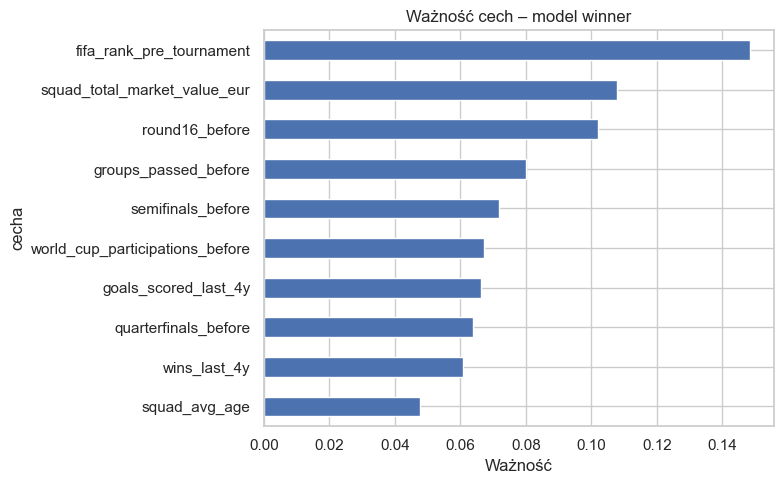

In [13]:
best_models = {}
best_model_names = {}

for target in target_cols:
    phase_results = cv_df[cv_df["Faza"] == target].sort_values("ROC AUC", ascending=False)
    best_name = phase_results.iloc[0]["Model"]
    best_auc = phase_results.iloc[0]["ROC AUC"]

    best_model_names[target] = best_name
    best_models[target] = fitted_models[(best_name, target)]

best_selection = pd.DataFrame({
    "Faza": target_cols,
    "Najlepszy model": [best_model_names[t] for t in target_cols],
    "ROC AUC (CV)": [
        cv_df[(cv_df["Faza"] == t) & (cv_df["Model"] == best_model_names[t])]["ROC AUC"].values[0]
        for t in target_cols
    ],
})

print("Wybrane modele do predykcji:")
best_selection

Dla najlepszego modelu przewidującego zwycięzcę sprawdziłem, które cechy mają największy wpływ na predykcję.

In [ ]:
winner_model = best_models["winner"]
winner_model_name = best_model_names["winner"]

if hasattr(winner_model, "feature_importances_"):
    importances = winner_model.feature_importances_
elif hasattr(winner_model, "named_steps"):
    importances = np.abs(winner_model.named_steps["clf"].coef_[0])
else:
    importances = np.abs(winner_model.coef_[0])

importance = pd.DataFrame({
    "cecha": X_train.columns,
    "ważność": importances,
}).sort_values("ważność", ascending=False)

print(f"Top 10 cech – najlepszy model zwycięzcy ({winner_model_name}):")
print(importance.head(10).to_string(index=False))

importance.head(10).plot(x="cecha", y="ważność", kind="barh", legend=False, figsize=(8, 5))
plt.title(f"Ważność cech – {winner_model_name} (winner)")
plt.xlabel("Ważność")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Najważniejsze predyktory to wartość rynkowa składu, ranking FIFA przed turniejem oraz historia startów w fazie pucharowej (m.in. `round16_before`, `quarterfinals_before`). Potwierdza to, że siła drużyny przed turniejem i doświadczenie w poprzednich edycjach MŚ mają kluczowe znaczenie.

### Krok 8 – Predykcja dla MŚ 2026
Na podstawie najlepszych modeli (wybranych w kroku 7) obliczyłem prawdopodobieństwa awansu każdej z 48 drużyn biorących udział w turnieju 2026. Jako kandydatów do danej fazy wybieram drużyny z najwyższym prawdopodobieństwem (top 8 / top 4 / top 2 / top 1).

In [14]:
predictions = test[["team", "continent", "fifa_rank_pre_tournament", "is_host"]].copy()

for target in target_cols:
    predictions[f"P({target})"] = best_models[target].predict_proba(X_test)[:, 1]
    predictions[f"model_{target}"] = best_model_names[target]

predictions = predictions.sort_values("P(winner)", ascending=False)
predictions.head(10)

,team,continent,fifa_rank_pre_tournament,is_host,P(quarter_finalist),P(semi_finalist),P(finalist),P(winner)
0,France,Europe,1,0,0.565,0.500,0.615,0.440
1,Spain,Europe,2,0,0.750,0.640,0.430,0.435
2,Argentina,South America,3,0,0.795,0.480,0.485,0.355
6,Netherlands,Europe,7,0,0.635,0.445,0.330,0.255
3,England,Europe,4,0,0.570,0.515,0.495,0.230
4,Portugal,Europe,5,0,0.635,0.540,0.360,0.110
15,Uruguay,South America,17,0,0.440,0.300,0.175,0.110
7,Morocco,Africa,8,0,0.530,0.545,0.405,0.090
13,Mexico,North America,15,1,0.300,0.125,0.065,0.090
17,Switzerland,Europe,19,0,0.395,0.250,0.100,0.085


In [15]:
def top_teams(df, prob_col, n):
    return df.nlargest(n, prob_col)[["team", prob_col]].reset_index(drop=True)

quarter = top_teams(predictions, "P(quarter_finalist)", 8)
semi = top_teams(predictions, "P(semi_finalist)", 4)
final = top_teams(predictions, "P(finalist)", 2)
champion = top_teams(predictions, "P(winner)", 1)

print("=== Prognoza: ćwierćfinały (top 8) ===")
print(quarter.to_string(index=False))

print("\n=== Prognoza: półfinały (top 4) ===")
print(semi.to_string(index=False))

print("\n=== Prognoza: finał (top 2) ===")
print(final.to_string(index=False))

print("\n=== Prognoza: zwycięzca ===")
print(champion.to_string(index=False))

=== Prognoza: ćwierćfinały (top 8) ===
       team  P(quarter_finalist)
  Argentina                0.795
      Spain                0.750
Netherlands                0.635
   Portugal                0.635
    England                0.570
     France                0.565
    Morocco                0.530
    Belgium                0.515

=== Prognoza: półfinały (top 4) ===
    team  P(semi_finalist)
   Spain             0.640
 Morocco             0.545
Portugal             0.540
 Senegal             0.530

=== Prognoza: finał (top 2) ===
   team  P(finalist)
 France        0.615
England        0.495

=== Prognoza: zwycięzca ===
  team  P(winner)
France       0.44


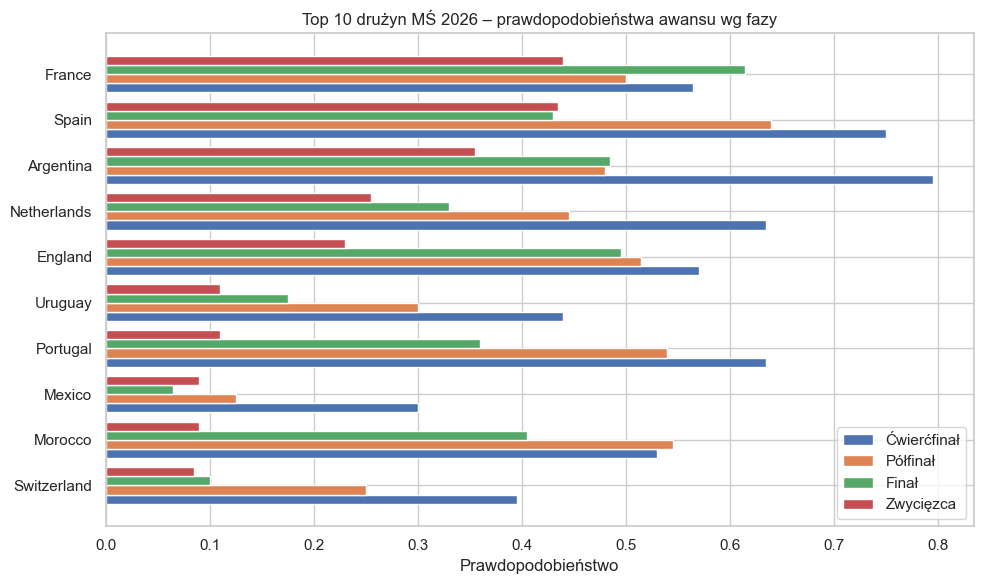

In [16]:
top10 = predictions.head(10).sort_values("P(winner)")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top10))
width = 0.2

ax.barh(x - 1.5 * width, top10["P(quarter_finalist)"], width, label="Ćwierćfinał")
ax.barh(x - 0.5 * width, top10["P(semi_finalist)"], width, label="Półfinał")
ax.barh(x + 0.5 * width, top10["P(finalist)"], width, label="Finał")
ax.barh(x + 1.5 * width, top10["P(winner)"], width, label="Zwycięzca")

ax.set_yticks(x)
ax.set_yticklabels(top10["team"])
ax.set_xlabel("Prawdopodobieństwo")
ax.set_title("Top 10 drużyn MŚ 2026 – prawdopodobieństwa awansu wg fazy")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Najlepsze modele wskazują na **Francję** jako drużynę z największym prawdopodobieństwem wygrania turnieju, tuż przed **Hiszpanią** i **Argentyną**. W ćwierćfinały prognozowany jest m.in. awans reprezentacji z Europy i Ameryki Południowej o wysokim rankingu FIFA.

Warto zauważyć, że gospodarze turnieju (Meksyk, USA, Kanada) mają przewagę własnego boiska (`is_host=1`), co model uwzględnia jako jedną z cech, jednak nie gwarantuje to automatycznie głębokiego awansu – ich szanse zależą głównie od rankingu i formy.

### Krok 9 – Podsumowanie porównania modeli
Poniżej zestawiłem wyniki wszystkich algorytmów oraz wskazałem, który model został wybrany do każdej fazy turnieju.

In [ ]:
comparison_summary = cv_df.merge(
    best_selection[["Faza", "Najlepszy model"]],
    on="Faza",
    how="left",
)
comparison_summary["Wybrany"] = comparison_summary.apply(
    lambda row: "✓" if row["Model"] == row["Najlepszy model"] else "",
    axis=1,
)

print("Pełne wyniki porównania modeli (✓ = wybrany do predykcji):")
comparison_summary[["Model", "Faza", "ROC AUC", "Odch. std.", "Wybrany"]]

print("\nRanking modeli (średni ROC AUC):")
print(model_summary.to_string())

print("\nWybrane modele do prognozy MŚ 2026:")
print(best_selection.to_string(index=False))

**Random Forest** i **Logistic Regression** osiągają najwyższy średni ROC AUC (~0,76–0,78) i najczęściej wygrywają w porównaniu faz. **XGBoost** jest silny przy przewidywaniu ćwierćfinałów, natomiast **Gradient Boosting** (sklearn) słabiej radzi sobie z rzadkimi klasami (`finalist`, `winner`).

Do końcowej predykcji wybrałem dla każdej fazy model z najlepszym wynikiem CV – dzięki temu wykorzystujemy mocne strony różnych algorytmów zamiast jednego uniwersalnego modelu.

# Wnioski

Na podstawie przeprowadzonej analizy i predykcji wyciągnąłem następujące wnioski:

1. **EDA** – dane historyczne obejmują 6 turniejów (2002–2022) i zawierają zarówno cechy sportowe (bramki, wygrane), jak i kontekstowe (ranking FIFA, wartość składu, doświadczenie w MŚ). Drużyny awansujące do późniejszych faz mają systematycznie lepsze wskaźniki we wszystkich tych kategoriach.

2. **Porównanie modeli** – przetestowałem cztery algorytmy (Random Forest, Gradient Boosting, Logistic Regression, XGBoost). Najlepsze wyniki w walidacji krzyżowej osiągają **Random Forest** i **Logistic Regression** (ROC AUC ok. 0,76–0,86 w zależności od fazy). Do predykcji MŚ 2026 wybrałem dla każdej fazy model z najwyższym AUC.

3. **Prognoza MŚ 2026** – największe szanse na zwycięstwo ma **Francja**, a w gronie faworytów znajdują się również **Hiszpania**, **Argentyna** i **Anglia**. Do ćwierćfinałów typowane jest 8 reprezentacji o najwyższym `P(quarter_finalist)`.

4. **Ograniczenia** – model uczy się na niewielkim zbiorze (192 obserwacje) i nie uwzględnia czynników trudnych do zakodowania (np. kontuzje, losowość pojedynków pucharowych). Predykcje mają charakter probabilistyczny i służą do wsparcia analizy, a nie jako jednoznaczna prognoza wyników sportowych.